In [1]:
import pandas as pd 
import numpy as np
import requests

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import os

In [3]:
band_df = pd.read_csv("../data/raw/crop_health_assesment_dataset.csv")
band_df['date'] = pd.to_datetime(band_df['date'])

band_df = band_df.sort_values(['lat', 'lon', 'date'])
band_df.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B8', 'EVI', 'NDVI',
       'NDWI', 'SAVI', 'date', 'lat', 'lon', '.geo'],
      dtype='object')

In [4]:
band_df.shape

(4779, 15)

In [5]:
# weather data
def get_weather_data(lat, lon, start_date, end_date):
    """
    Fetch weather data from NASA POWER API
    """

    url = f"https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "parameters": "T2M,RH2M",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": start_date,
        "end": end_date,
        "format": "JSON"
    }

    response = requests.get(url, params=params)
    data = response.json()

    df = pd.DataFrame(data["properties"]["parameter"])

    df = df.reset_index().rename(columns={"index": "date"})

    # Rename columns
    df = df.rename(columns={
        "T2M": "temperature",
        "RH2M": "humidity"
    })

    return df

# Weather
sample_lat = band_df['lat'].iloc[0]
sample_lon = band_df['lon'].iloc[0]

weather_df = get_weather_data(
    lat=sample_lat,
    lon=sample_lon,
    start_date="20230101",
    end_date="20231231"
)
weather_df['date'] = pd.to_datetime(weather_df['date'])


In [6]:
df = pd.merge(band_df, weather_df, on='date', how='left')

with pd.option_context('display.max_columns', None):
    print(df.head())

                                    system:index   B11   B12    B2    B3  \
0  20230117T045131_20230117T045127_T45RTH_2_45_0  2928  2152  1628  1750   
1  20230120T050121_20230120T050119_T45RTH_2_45_0  2761  2044  1812  1927   
2  20230125T050059_20230125T051013_T45RTH_2_45_0  2903  2160  1221  1385   
3  20230127T045051_20230127T045956_T45RTH_2_45_0  3157  2357  2106  2148   
4  20230130T050041_20230130T051047_T45RTH_2_45_0  2850  2167  1272  1461   

     B4    B8       EVI      NDVI      NDWI      SAVI       date        lat  \
0  1686  3188  3.429224  0.308166 -0.291211  0.462201 2023-01-17  24.495982   
1  1842  3002  6.236559  0.239472 -0.218097  0.359170 2023-01-20  24.495982   
2  1408  2766  1.650061  0.325347 -0.332691  0.487963 2023-01-25  24.495982   
3  2042  3148 -7.017766  0.213102 -0.188822  0.319622 2023-01-27  24.495982   
4  1574  2660  1.058480  0.256495 -0.290949  0.384697 2023-01-30  24.495982   

         lon                                               .geo  tem

In [7]:
df.to_csv("../data/raw/band_weather.csv")

In [33]:
df=pd.read_csv('../data/raw/band_weather.csv')
df.drop("Unnamed: 0",axis=1,inplace=True)
df['date'] = pd.to_datetime(df['date'])
df.head()

,system:index,B11,B12,B2,B3,B4,B8,NDVI,NDWI,date,lat,lon,.geo,temperature,humidity,precipitation
0,20230102T054231_20230102T054230_T43RDP_14_0,2704,2187,1338,1679,1621,2962,0.292603,-0.276449,2023-01-02,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""...",12.48,34.88,0.0
1,20230117T054149_20230117T054149_T43RDP_14_0,2497,1947,1471,1691,1504,3338,0.378769,-0.327501,2023-01-17,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""...",11.28,16.24,0.0
2,20230127T054109_20230127T054834_T43RDP_14_0,2447,1832,1372,1578,1375,4008,0.489132,-0.435016,2023-01-27,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""...",11.43,34.53,0.0
3,20230201T054041_20230201T054044_T43RDP_14_0,2383,1699,1281,1531,1296,4188,0.527352,-0.464592,2023-02-01,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""...",13.79,51.37,0.0
4,20230206T054019_20230206T054847_T43RDP_14_0,2549,1864,1218,1472,1260,4652,0.573748,-0.519268,2023-02-06,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""...",18.80,35.46,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4779 entries, 0 to 4778
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   system:index  4779 non-null   object        
 1   B11           4779 non-null   int64         
 2   B12           4779 non-null   int64         
 3   B2            4779 non-null   int64         
 4   B3            4779 non-null   int64         
 5   B4            4779 non-null   int64         
 6   B8            4779 non-null   int64         
 7   EVI           4779 non-null   float64       
 8   NDVI          4779 non-null   float64       
 9   NDWI          4779 non-null   float64       
 10  SAVI          4779 non-null   float64       
 11  date          4779 non-null   datetime64[ns]
 12  lat           4779 non-null   float64       
 13  lon           4779 non-null   float64       
 14  .geo          4779 non-null   object        
 15  temperature   4779 non-null   float64 

In [9]:
features = ['EVI', 'NDVI','NDWI', 'SAVI', 'temperature', 'humidity']


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

In [11]:
df[features]

,EVI,NDVI,NDWI,SAVI,temperature,humidity
0,0.384307,0.582061,0.557744,0.582040,0.020973,0.233730
1,0.387558,0.511045,0.615356,0.511024,0.113573,0.296825
2,0.382246,0.599824,0.525058,0.599797,0.318955,0.352381
3,0.372207,0.483784,0.638425,0.483765,0.275425,0.599206
4,0.381561,0.528644,0.557950,0.528619,0.267907,0.164153
...,...,...,...,...,...,...
4774,0.386749,0.485640,0.621076,0.485622,0.232291,0.559524
4775,0.384720,0.556393,0.575178,0.556372,0.371191,0.623280
4776,0.383032,0.537735,0.585125,0.537714,0.230708,0.814947
4777,0.382439,0.546598,0.570518,0.546575,0.086268,0.506085


In [61]:
print(df[features].describe())

               EVI         NDVI         NDWI         SAVI  temperature  \
count  4779.000000  4779.000000  4779.000000  4779.000000  4779.000000   
mean      0.382471     0.578700     0.545658     0.578684     0.457037   
std       0.016741     0.168227     0.101580     0.168230     0.245696   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.381068     0.436977     0.467912     0.436960     0.279383   
50%       0.382060     0.559260     0.556587     0.559240     0.402849   
75%       0.383271     0.723026     0.617937     0.723012     0.619707   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

          humidity  
count  4779.000000  
mean      0.385870  
std       0.280815  
min       0.000000  
25%       0.125794  
50%       0.352381  
75%       0.623280  
max       1.000000  


In [47]:
df[features].min() , df[features].max()

(EVI            0.0
 NDVI           0.0
 NDWI           0.0
 SAVI           0.0
 temperature    0.0
 humidity       0.0
 dtype: float64,
 EVI            1.0
 NDVI           1.0
 NDWI           1.0
 SAVI           1.0
 temperature    1.0
 humidity       1.0
 dtype: float64)

In [15]:
# Split by date (better than random)
split_date = df['date'].quantile(0.8)

df_train = df[df['date'] <= split_date]
df_test  = df[df['date'] > split_date]

print(df_train.shape, df_test.shape)

(3828, 17) (951, 17)


In [84]:
# Split by date (better than random)
# split_date = df_train['date'].quantile(0.8)

# df_val  = df_train[df_train['date'] > split_date]
# df_train = df_train[df_train['date'] <= split_date]


# print(df_train.shape, df_val.shape)

In [16]:
def create_sequences_autoencoder(df, seq_length=10):
    X = []

    for (lat, lon), group in df.groupby(['lat', 'lon']):
        group = group.sort_values('date')

        data = group[features].values

        for i in range(len(group) - seq_length):
            X.append(data[i:i+seq_length])

    return np.array(X)

In [62]:
seq_length = 20

X_train = create_sequences_autoencoder(df_train, seq_length)
X_test  = create_sequences_autoencoder(df_test, seq_length)
# X_val  = create_sequences_autoencoder(df_val, seq_length)

# print(X_train.shape, X_test.shape,X_val.shape)
print(X_train.shape, X_test.shape)

(1728, 20, 6) (39, 20, 6)


In [87]:
X_train[0]

array([[0.38430679, 0.58206113, 0.5577437 , 0.58204007, 0.02097349,
        0.23373016],
       [0.3875584 , 0.51104467, 0.61535638, 0.51102396, 0.11357341,
        0.2968254 ],
       [0.38224607, 0.59982354, 0.52505819, 0.59979659, 0.31895528,
        0.35238095],
       [0.37220654, 0.48378388, 0.63842478, 0.48376488, 0.27542541,
        0.59920635],
       [0.38156087, 0.52864366, 0.55795031, 0.52861888, 0.26790661,
        0.16415344],
       [0.38208846, 0.59583264, 0.52677792, 0.59580679, 0.18480412,
        0.23796296],
       [0.38183112, 0.57341759, 0.5315145 , 0.57339482, 0.24297586,
        0.2484127 ],
       [0.38155096, 0.52023352, 0.56645661, 0.52020916, 0.22437673,
        0.14669312],
       [0.38209375, 0.55626409, 0.55092039, 0.556242  , 0.34230313,
        0.13320106],
       [0.38149842, 0.50701067, 0.56628661, 0.50698799, 0.16580926,
        0.07156085]])

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # autoencoders → use reconstruction loss
    patience=10,             # wait 5 epochs before stopping
    restore_best_weights=True
)

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

In [21]:
from tensorflow.keras.layers import Dropout

In [22]:
from tensorflow.keras.layers import Input

In [77]:
model = Sequential([
    
    # 🔹 Encoder
    Input(shape=(seq_length, len(features))),
    LSTM(64, activation='tanh', return_sequences=True,
         ),
    Dropout(0.1),
    
    LSTM(32, activation='tanh', return_sequences=False),
    
    # 🔹 Bottleneck
    RepeatVector(seq_length),
    
    # 🔹 Decoder
    LSTM(32, activation='tanh', return_sequences=True),
    Dropout(0.1),
    
    LSTM(64, activation='tanh', return_sequences=True),
    
    # 🔹 Output
    TimeDistributed(Dense(len(features), activation='sigmoid'))
])


In [78]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [79]:
model.compile(optimizer='adam', loss='mae')
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 20, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 20, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 20, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 6)          │           390 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,134 (250.52 KB)

 Trainable params: 64,134 (250.52 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = model.fit(
    X_train, X_train,          # autoencoder → input = output
    epochs=60,
    batch_size=16,
    validation_data=(X_test, X_test),
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 0.1206 - val_loss: 0.1027 - learning_rate: 0.0010
Epoch 2/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0831 - val_loss: 0.0936 - learning_rate: 0.0010
Epoch 3/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.0705 - val_loss: 0.0936 - learning_rate: 0.0010
Epoch 4/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0656 - val_loss: 0.0997 - learning_rate: 0.0010
Epoch 5/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.0610 - val_loss: 0.1007 - learning_rate: 0.0010
Epoch 6/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0575 - val_loss: 0.1036 - learning_rate: 0.0010
Epoch 7/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0552 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 8/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0532 - val_loss: 0.0936 - learning_rate: 0.0010
Epoch 9/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.0523 - val_loss: 0.0848 - learning_rate: 0.0010


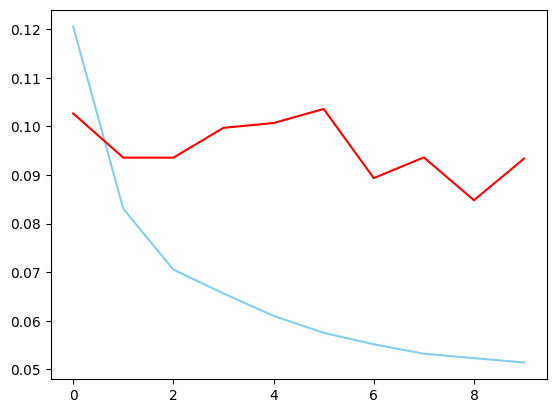

In [81]:
plt.plot(history.history['loss'],label='loss',color='skyblue')
plt.plot(history.history['val_loss'],label='val_loss',color='red')

In [82]:
reconstructions = model.predict(X_test)

errors = np.mean((X_test - reconstructions)**2, axis=(1,2))

threshold = np.percentile(errors, 95)

anomaly = (errors > threshold).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 829ms/step


In [83]:
threshold

0.04257788817468353

In [84]:
errors

array([0.01823756, 0.01867134, 0.01949395, 0.020279  , 0.021153  ,
       0.02204383, 0.02291206, 0.01813254, 0.01873646, 0.01920785,
       0.01983643, 0.02071293, 0.0114213 , 0.01160054, 0.01170006,
       0.01208181, 0.01239982, 0.01297746, 0.01357173, 0.01419039,
       0.01395811, 0.01382927, 0.01330303, 0.01323705, 0.01517719,
       0.01706879, 0.01878165, 0.02063576, 0.02166692, 0.02337902,
       0.02411192, 0.02659209, 0.02936383, 0.03232299, 0.03531116,
       0.03911133, 0.04235694, 0.04456645, 0.04603665])

In [85]:
t=0
for i in anomaly:
    if i==1:
        print(t)
    t=t+1

37
38


In [94]:
print("Mean error:", errors.mean())
print("Std error:", errors.std())

Mean error: 0.02128641546652054
Std error: 0.009216366339349654


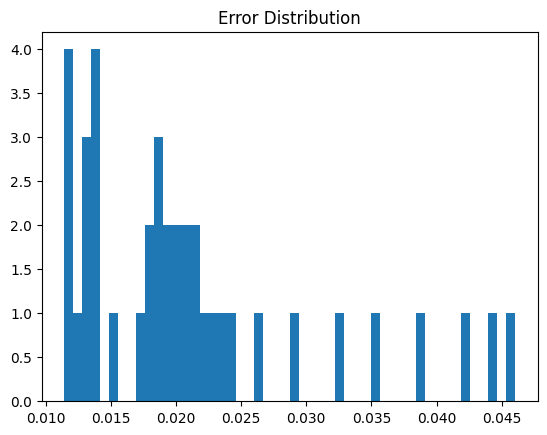

In [87]:
import matplotlib.pyplot as plt

plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()

<Axes: ylabel='Count'>

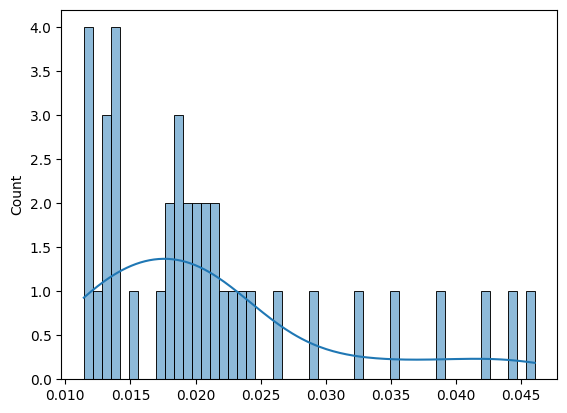

In [88]:
sns.histplot(errors,kde=True,bins=50)

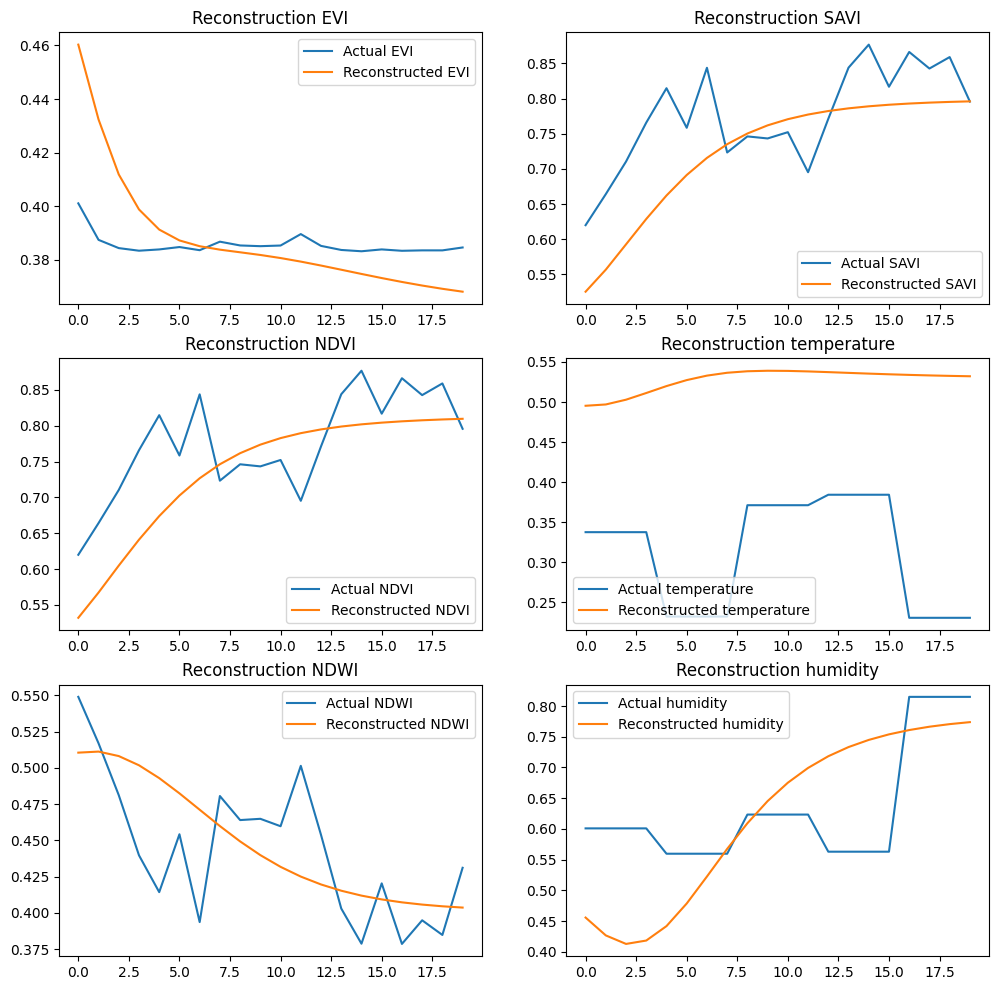

In [93]:
fig,ax=plt.subplots(3,2,figsize=(12,12))
idx = 23

actual = X_test[idx]
reconstructed = reconstructions[idx]

features=['EVI', 'NDVI','NDWI', 'SAVI', 'temperature', 'humidity']
for i in range(3):
  
    ax[i][0].plot(actual[:,i], label=f'Actual {features[i]}')
    ax[i][0].plot(reconstructed[:,i], label=f'Reconstructed {features[i]}')
    ax[i][0].legend()
    ax[i][0].set_title(f"Reconstruction {features[i]}")

    ax[i][1].plot(actual[:,i+3], label=f'Actual {features[i+3]}')
    ax[i][1].plot(reconstructed[:,i+3], label=f'Reconstructed {features[i+3]}')
    ax[i][1].legend()
    ax[i][1].set_title(f"Reconstruction {features[i+3]}")


plt.show()

In [59]:
print("Anomaly %:", anomaly.mean()*100)

Anomaly %: 5.109489051094891


In [74]:
anomaly_idx = np.where(anomaly == 1)[0]

for i in anomaly_idx[:5]:
    print("Index:", i)
    print("NDVI sequence:", X_test[i][:,0])
    print()

Index: 37
NDVI sequence: [0.38315005 0.38383906 0.38332747 0.38348364 0.38347973 0.38456331
 0.38389662 0.38402081 0.38550116 0.38327806 0.38454297 0.38302239
 0.38358086 0.38374583 0.38349124 0.383292   0.38383063 0.38459092
 0.3876928  0.38561429]

Index: 38
NDVI sequence: [0.38383906 0.38332747 0.38348364 0.38347973 0.38456331 0.38389662
 0.38402081 0.38550116 0.38327806 0.38454297 0.38302239 0.38358086
 0.38374583 0.38349124 0.383292   0.38383063 0.38459092 0.3876928
 0.38561429 0.38540028]



# try

In [62]:
errors = np.mean(abs(X_test - reconstructions), axis=(1,2))

threshold = np.percentile(errors, 95)

anomaly = (errors > threshold).astype(int)

In [63]:
anomaly_idx = np.where(anomaly == 1)[0]

for i in anomaly_idx[:5]:
    print("Index:", i)
    print("NDVI sequence:", X_test[i][:,0])
    print()

Index: 52
NDVI sequence: [0.3816724  0.38372816 0.38213946 0.38167838 0.3829329  0.38500614
 0.38340931 0.38350253 0.38290212 0.38714729]

Index: 67
NDVI sequence: [0.38236269 0.38404313 0.38232004 0.38211277 0.38282663 0.38323052
 0.41481039 0.31467449 0.3825688  0.38665072]

Index: 68
NDVI sequence: [0.38404313 0.38232004 0.38211277 0.38282663 0.38323052 0.41481039
 0.31467449 0.3825688  0.38665072 0.38323602]

Index: 69
NDVI sequence: [0.38232004 0.38211277 0.38282663 0.38323052 0.41481039 0.31467449
 0.3825688  0.38665072 0.38323602 0.38374734]

Index: 70
NDVI sequence: [0.38211277 0.38282663 0.38323052 0.41481039 0.31467449 0.3825688
 0.38665072 0.38323602 0.38374734 0.38267777]



In [69]:
anomaly[anomaly==True]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [70]:
def date (df):
    for (lat, lon), group in df.groupby(['lat', 'lon']):
        group = group.sort_values('date')

        date = group['date'].values

        

    return date

In [71]:
date=date(df_test)
date

array(['2023-11-13T00:00:00.000000000', '2023-11-23T00:00:00.000000000',
       '2023-12-03T00:00:00.000000000', '2023-12-08T00:00:00.000000000',
       '2023-12-13T00:00:00.000000000', '2023-12-18T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [75]:
df['date']

array(['2023-01-17T00:00:00.000000000', '2023-01-20T00:00:00.000000000',
       '2023-01-25T00:00:00.000000000', ...,
       '2023-12-08T00:00:00.000000000', '2023-12-13T00:00:00.000000000',
       '2023-12-18T00:00:00.000000000'], dtype='datetime64[ns]')